# Myntra Customer Rating Prediction using Machine Learning

## Project Overview

This project aims to predict customer ratings for Myntra products using machine learning techniques. The project explores both:

- Multi-class Classification
- Regression

### Objectives

- Perform Exploratory Data Analysis (EDA)
- Engineer meaningful predictive features
- Apply statistical tests to identify significant variables
- Build Classification models to predict rating categories
- Build Regression models to predict exact customer ratings
- Compare different machine learning algorithms
- Generate actionable business recommendations

# 1.Business Understanding

## Problem Statement

Customer ratings directly impact customer trust, product visibility, and sales performance in e-commerce platforms such as Myntra.

Being able to predict customer ratings before products accumulate reviews allows businesses to:

- Identify products likely to receive poor ratings
- Improve product quality and pricing strategies
- Monitor seller performance
- Enhance customer satisfaction

This project formulates the problem in two ways:

1. **Classification:** Predict whether a product belongs to a Low, Medium, or High rating category.
2. **Regression:** Predict the exact customer rating on a continuous scale.

# 2.Data Understanding

#### Import Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
from warnings import filterwarnings
filterwarnings('ignore')

pd.set_option('display.max_columns',None)

#### Loading Dataset

In [2]:
myntra=pd.read_csv(r"C:\Users\SAHITHI VITTAL\Documents\Projects\Capstone Project\archive\myntra202305041052.csv")
myntra.head()

,id,name,img,asin,price,mrp,rating,ratingTotal,discount,seller,purl
0,1,Men Solid Oversized Cotton,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",-,532.0,1299.0,4.1,5300,59,Difference of Opinion,https://www.myntra.com/tshirts/difference-of-o...
1,2,Men Cotton Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",-,274.0,499.0,4.2,25400,45,Roadster,https://www.myntra.com/tshirts/roadster/roadst...
2,3,Women Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",-,551.0,1199.0,4.5,3400,54,DILLINGER,https://www.myntra.com/tshirts/dillinger/dilli...
3,4,Typography Print T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",-,296.0,1099.0,4.0,18400,73,Huetrap,https://www.myntra.com/tshirts/huetrap/huetrap...
4,5,Printed Round Neck Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",-,494.0,899.0,4.2,3800,45,Roadster,https://www.myntra.com/tshirts/roadster/roadst...


#### Exploring Data

In [3]:
myntra.shape

(1060213, 11)

* Number of rows:1060213
* Number of Columns:11

In [4]:
myntra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060213 entries, 0 to 1060212
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   id           1060213 non-null  int64  
 1   name         1060213 non-null  object 
 2   img          1060213 non-null  object 
 3   asin         1060213 non-null  object 
 4   price        1060213 non-null  float64
 5   mrp          1060213 non-null  float64
 6   rating       1060213 non-null  float64
 7   ratingTotal  1060213 non-null  int64  
 8   discount     1060213 non-null  int64  
 9   seller       1060213 non-null  object 
 10  purl         1060213 non-null  object 
dtypes: float64(3), int64(3), object(5)
memory usage: 89.0+ MB


* Number of Numerical columns:06
* Number of Categorical columns:05

#### Checking Null Values

In [5]:
myntra.isnull().sum()

id             0
name           0
img            0
asin           0
price          0
mrp            0
rating         0
ratingTotal    0
discount       0
seller         0
purl           0
dtype: int64

* No Null values present in the dataset

#### Checking Duplicate Rows

In [6]:
myntra[myntra.duplicated()]

,id,name,img,asin,price,mrp,rating,ratingTotal,discount,seller,purl


* No duplicate rows in the data

#### Dropping Unwanted Columns

In [7]:
myntra['asin'].unique()

array(['-'], dtype=object)

In [8]:
# droping id and asin columns
myntra.drop(['id','asin', 'discount'],axis=1,inplace=True)

* Dropped ID because It is not an important Feature
* Dropping asin since it doesn't have any values
* Dropping discount because the values in it are in the combinations of rupees and percentile and we will create it using price and MRP in feature Engineering

#### Dropping Unwanted Rows

In [9]:
myntra['rating'].value_counts(normalize=True)

rating
0.0    0.744897
4.3    0.029545
4.4    0.027660
4.2    0.024506
4.5    0.022258
4.0    0.020282
4.1    0.019588
4.6    0.017082
3.8    0.012398
3.9    0.012135
4.7    0.010239
4.8    0.009506
3.7    0.007834
5.0    0.006731
3.6    0.006353
3.5    0.004876
3.4    0.003926
3.3    0.003552
3.0    0.003368
4.9    0.003192
3.2    0.002271
3.1    0.001213
2.8    0.001191
2.5    0.000718
2.7    0.000703
2.9    0.000681
2.6    0.000619
2.3    0.000578
2.0    0.000531
1.0    0.000438
2.4    0.000362
2.2    0.000191
1.5    0.000130
1.8    0.000124
1.7    0.000084
2.1    0.000067
1.3    0.000053
1.6    0.000048
1.9    0.000036
1.4    0.000023
1.2    0.000010
1.1    0.000002
Name: proportion, dtype: float64

##### Since rating=0 has no meaning and filling 74% of data(rating=0) can make the dataset biased.So choosed dropping rows was te best option 

In [10]:
## dropping missing values in rating column
myntra = myntra[myntra['rating'] != 0.]

In [11]:
myntra.shape

(270463, 8)

* No. of Rows:270463
* No. of Columns:08

# 3.Exploratory Data Analysis

EDA helps understand the distribution of variables, detect outliers, identify missing values, and discover relationships between product attributes and customer ratings before building predictive models.

## 3.1 Univariate Analysis

In [12]:
plt.rcParams['figure.figsize'] = [20,10]

In [13]:
myntra.columns

Index(['name', 'img', 'price', 'mrp', 'rating', 'ratingTotal', 'seller',
       'purl'],
      dtype='object')

In [14]:
num=myntra.select_dtypes(include=np.number).columns
num

Index(['price', 'mrp', 'rating', 'ratingTotal'], dtype='object')

#### Distribution Of Numerical Columns

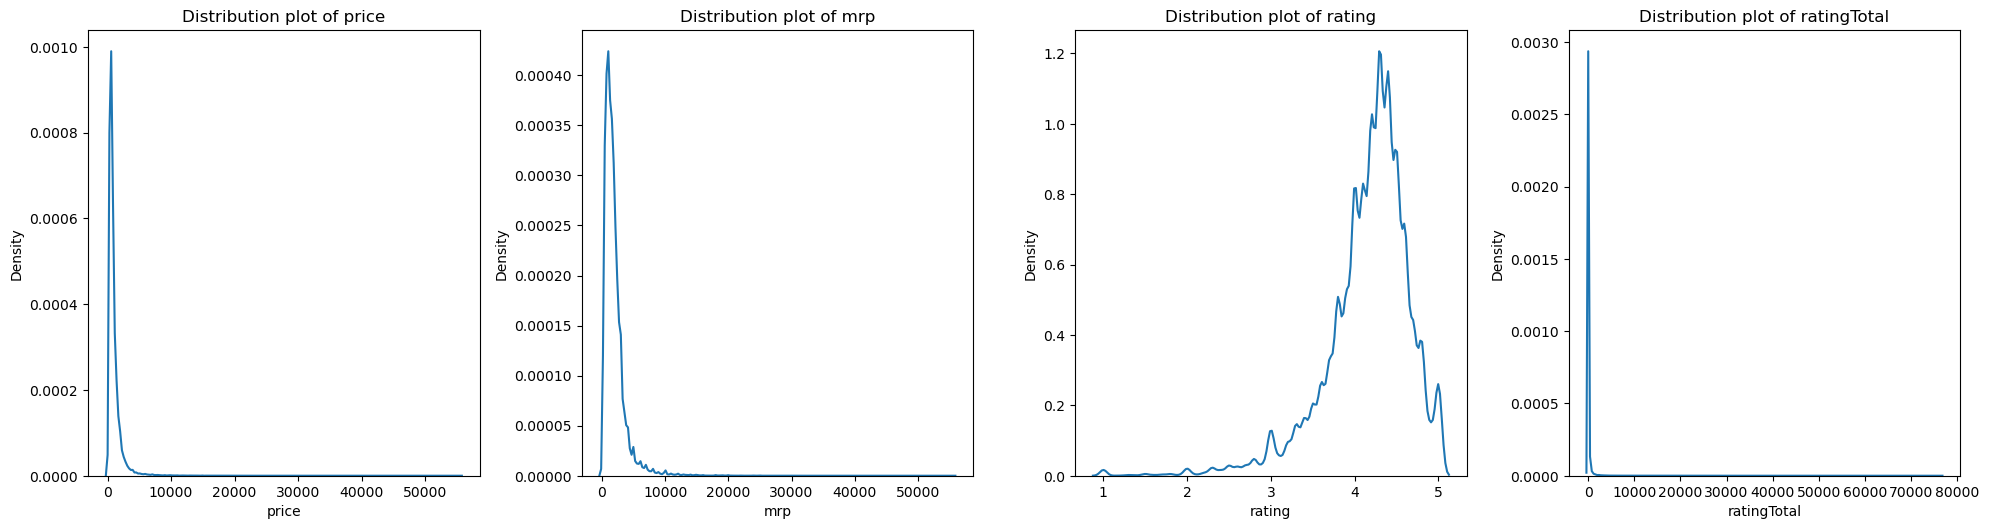

In [15]:
t=1
for i in num:
    plt.subplot(2,4,t)
    sns.kdeplot(myntra[i])
    plt.title(f'Distribution plot of {i}')
    t+=1
plt.tight_layout()
plt.show()

### Insights

- **Price and MRP:** Both variables exhibit a **highly right-skewed distribution**, indicating that most Myntra products are priced in the lower range, while a small number of premium products create long right tails. This suggests the presence of high-value outliers.

- **Customer Ratings:** Product ratings are concentrated between **4.0 and 4.5**, indicating that most products receive positive customer feedback. Very low ratings are comparatively rare.

- **Number of Ratings (`ratingTotal`):** The distribution is heavily right-skewed, showing that while most products have relatively few customer ratings, a small number of popular products accumulate a very large number of reviews.

#### OUTLIERS detection using boxplot for all numeric variable

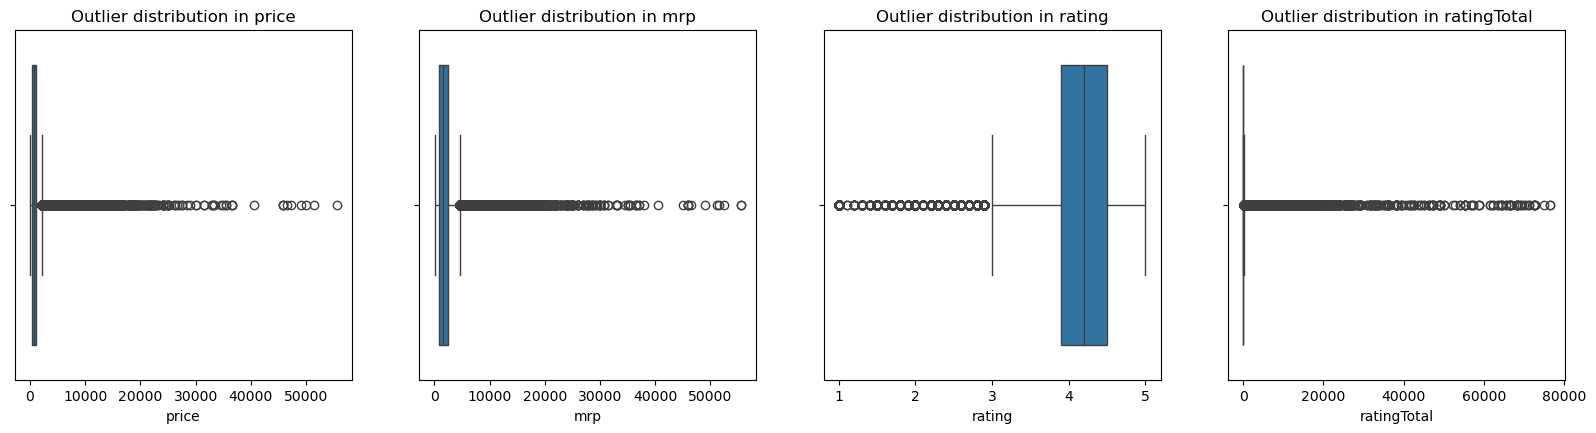

In [16]:
t = 1
for i in num:
    plt.subplot(2,4,t)
    sns.boxplot(x = myntra[i])
    plt.title(f'Outlier distribution in {i}')
    t+=1

plt.show()

### Insights

- **Price and MRP:** Both variables contain a considerable number of high-value outliers, reflecting the presence of premium-priced products in the dataset. These observations appear to be genuine values rather than data entry errors.

- **Customer Rating:** A small number of low-rated products are identified as outliers, while the majority of ratings are concentrated between **4.0 and 4.5**, indicating generally positive customer feedback.

- **Number of Ratings (`ratingTotal`):** The distribution contains several extreme outliers, showing that a few products have accumulated substantially more customer reviews than the rest of the catalog.

- **Modeling Consideration:** Since the outliers represent legitimate business observations rather than anomalies, they were **retained** for analysis. Tree-based algorithms such as **Decision Tree**, **Random Forest**, and **XGBoost** are generally robust to outliers and can effectively model such data without requiring outlier removal.

## 3.2 Bivariate Analysis

#### Rating vs Totalratings

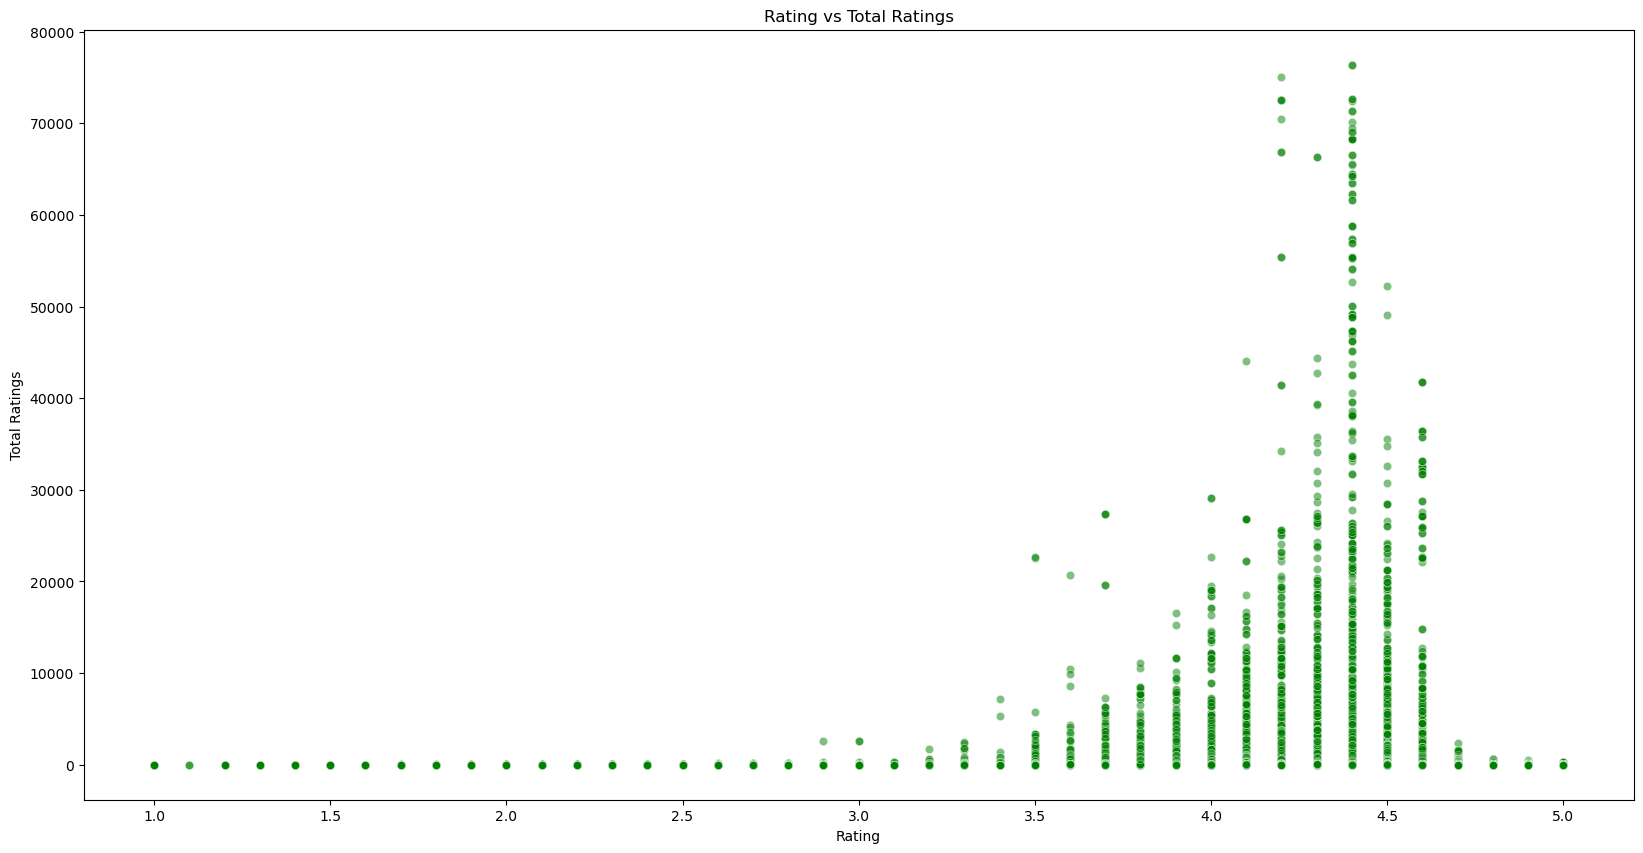

In [18]:
sns.scatterplot(y='ratingTotal', x='rating', data=myntra, alpha=0.5, color='green')
plt.title('Rating vs Total Ratings')
plt.xlabel('Rating')
plt.ylabel('Total Ratings')
plt.show()

### Insights

- Most products have ratings between **4.0 and 4.5**.
- Products with higher ratings generally receive more customer reviews.
- A few products have exceptionally high review counts, indicating highly popular products.

#### Sellers vs Products

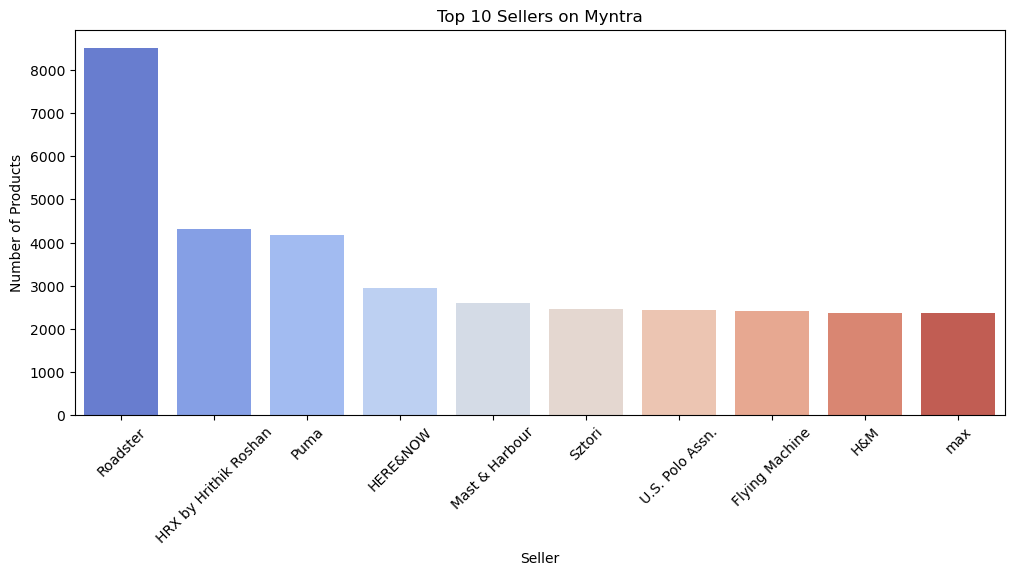

In [19]:
plt.figure(figsize=(12, 5))
top_sellers = myntra['seller'].value_counts().head(10)
sns.barplot(x=top_sellers.index, y=top_sellers.values, palette='coolwarm')
plt.xticks(rotation=45)
plt.title('Top 10 Sellers on Myntra')
plt.xlabel('Seller')
plt.ylabel('Number of Products')
plt.show()

### Insights

- **Roadster** has the highest number of listed products, followed by **HRX by Hrithik Roshan** and **Puma**.
- A few sellers contribute a large share of the product catalog, indicating an uneven distribution across sellers.
- Seller information may be an important feature for predicting customer ratings.

## 3.3 Multivariate Analysis

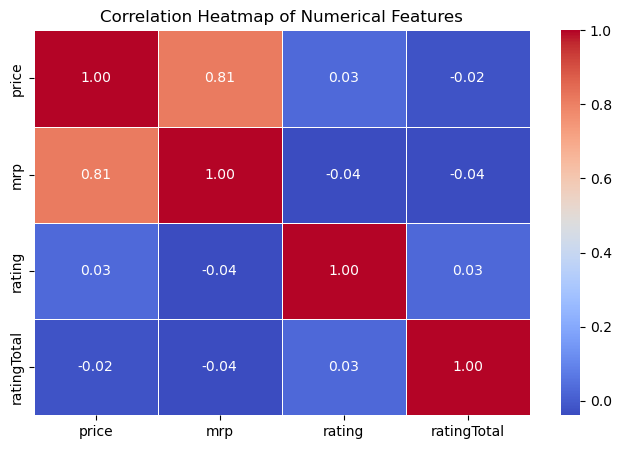

In [20]:
plt.figure(figsize=(8, 5))
sns.heatmap(myntra[['price', 'mrp', 'rating', 'ratingTotal']].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Insights

- Price and MRP are strongly positively correlated (**0.81**).
- Rating has a weak relationship with other numerical features.
- Most numerical features show low correlation, reducing multicollinearity concerns.

## Check Skewness

In [21]:
# skewness between all the numeric variables
for i in num:
    if myntra[i].skew()>0:
        print(f'{i}: is positively skewed')
    elif myntra[i].skew()<0:
        print(f'{i}: is negatively skewed')
    else:
        print(f'{i}: has zero skewness')
        

#INFERENCE: all of the numeric variables are positvely skewed in nature

price: is positively skewed
mrp: is positively skewed
rating: is negatively skewed
ratingTotal: is positively skewed


## Check Kurtosis

In [22]:
# kurtosis among all the numeric variables
for i in num:
    if myntra[i].kurt()>3:
        print(f'{i}:  is leptokurtic, evidence of huge presence of outliers')
    elif myntra[i].kurt()==3:
        print(f'{i}:  is mesokurtic, normal distribution')
    elif myntra[i].kurt()<3:
        print(f'{i}:  is platykurtic, fewer presence of outliers')
    else:
        end

price:  is leptokurtic, evidence of huge presence of outliers
mrp:  is leptokurtic, evidence of huge presence of outliers
rating:  is leptokurtic, evidence of huge presence of outliers
ratingTotal:  is leptokurtic, evidence of huge presence of outliers


# 4. Feature Engineering
Several new features were created to improve predictive performance.

#### Extracting 'sub-category' from 'purl'

In [23]:
myntra['sub_category'] = myntra['purl'].str.split('/').str[3]
myntra.head(1)

,name,img,price,mrp,rating,ratingTotal,seller,purl,sub_category
0,Men Solid Oversized Cotton,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",532.0,1299.0,4.1,5300,Difference of Opinion,https://www.myntra.com/tshirts/difference-of-o...,tshirts


In [24]:
print('count of unique sub-categories:', myntra.sub_category.nunique())
print("****")
print(myntra.sub_category.value_counts(normalize = True))

count of unique sub-categories: 338
****
sub_category
tshirts              0.218725
jeans                0.037447
bra                  0.034256
dresses              0.025405
track-pants          0.022961
                       ...   
wristbands           0.000004
tablet-sleeve        0.000004
hooks-and-holders    0.000004
pagri-and-safa       0.000004
baby-utensils        0.000004
Name: proportion, Length: 338, dtype: float64


#### Extracting 'gender' from 'name'

In [25]:
import re

#Function to classify gender based on regex match
def classify_gender(name):
    if re.search(r'\bmen|male|guys|gentlemen|boys|mister\b', name, re.IGNORECASE):
        return 'Male'
    elif re.search(r'\bwomen|female|ladies|girls|misses\b', name, re.IGNORECASE):
        return 'Female'
    elif re.search(r'\bunnisex|unisex|gender-neutral|both\b', name, re.IGNORECASE):
        return 'Unisex'
    else:
        return 'Unknown'  # In case no gender term is found

In [26]:
myntra['gender'] = myntra['name'].apply(classify_gender)
myntra.head(1)

,name,img,price,mrp,rating,ratingTotal,seller,purl,sub_category,gender
0,Men Solid Oversized Cotton,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",532.0,1299.0,4.1,5300,Difference of Opinion,https://www.myntra.com/tshirts/difference-of-o...,tshirts,Male


In [27]:
myntra['gender'].value_counts(normalize=True)

gender
Unknown    0.485323
Male       0.291689
Female     0.181870
Unisex     0.041118
Name: proportion, dtype: float64

*INFERENCE:*

- We see huge data in 'Unknown' stating that majority of the product name doesn't specify which gender does it belong to. So, checking which all sub-categories does 'unknown' gender belong to and manually classifying those sub-categories to 'men', 'women' and 'unisex' considering only 3 genders.

In [28]:
myntra[myntra['gender']=='Unknown']['sub_category'].unique()

array(['tshirts', 'body-wash-and-scrub', 'shapewear', 'leggings',
       'kurta-sets', 'kurtas', 'tops', 'shampoo-and-conditioner',
       'face-serum-and-gel', 'gold-coin', 'jewellery-set', 'earrings',
       'track-pants', 'briefs', 'boxers', 'trunk', 'socks',
       'lounge-pants', 'lounge-tshirts', 'innerwear-vests', 'shirts',
       'tracksuits', 'sports-shoes', 'jeans', 'sunscreen',
       'face-moisturisers', 'shaving-essentials', 'body-lotion',
       'perfume-and-body-mist', 'face-wash-and-cleanser', 'trimmer',
       'hair-serum', 'hair-oil', 'hair-appliance', 'deodorant',
       'headphones', 'smart-watches', 'trolley-bag', 'clothing-set',
       'flip-flops', 'casual-shoes', 'night-suits', 'dresses',
       'activity-toys-and-games', 'soft-toys-and-dolls',
       'learning-and-development-toys', 'bb-and-cc-cream', 'foundation',
       'kajal-and-eyeliner', 'lipstick', 'mascara', 'face-primer',
       'compact', 'makeup-remover', 'lip-care', 'epilator',
       'shaving-brush

In [29]:
# Categories
male = ['Men','Boys','smart-watches', 'watches', 'sherwani', 'jackets', 'nehru-jackets', 'trousers', 'boxers',
        'lounge-pants', 'lounge-tshirts', 'innerwear-vests', 'tracksuits', 'jeans', 'shaving-essentials',
        'beard-and-moustache-care', 'trimmer', 'ties-and-cufflinks', 'belts', 'formal-shoes', 'sports-shoes', 'wallets', 'suspenders', 'helmets',
         'briefs', 'trunk', 'face-serum-and-gel',  'flip-flops', 'casual-shoes', 'shaving-brush--razor', 'beard--moustache-care',
        'sports-sandals', 'mens-grooming-kit', 'suits', 'waistcoat', 'boots','dhotis','cufflinks','runners']

female = ['tshirts', 'shirts', 'tops', 'dresses', 'co-ords', 'jumpsuit', 'kurtas', 'sarees', 'lehenga-choli','breast-pumps',
         'kurta-sets', 'ethnic-dresses', 'kurtis', 'skirts', 'tunics', 'shrug', 'stoles', 'scarves', 'heels', 'flats','dupatta', 'nightdress',
         'bra', 'camisoles', 'lingerie-set', 'baby-dolls', 'night-suits', 'shapewear', 'saree-blouse', 'salwar','breast-pumps'
         'dupatta', 'patiala', 'jeggings', 'leggings', 'anklet', 'bangles', 'earrings', 'necklace-and-chains','capris','baby-nail-grooming',
         'mangalsutra', 'nosepin', 'rings', 'bracelet', 'jewellery-set', 'makeup-kit','face-moisturisers','dungarees', 'body-lotion', 'face-wash-and-cleanser', 'foundation', 'kajal-and-eyeliner',
        'lipstick', 'mascara', 'face-primer', 'compact', 'makeup-remover', 'lip-care', 'epilator', 'toner','highlighter-and-blush', 'makeup-gift-set', 'skin-care-gift-set', 'swimwear-accessories', 
         'swim-bottoms', 'bangle', 'lounge-shorts', 'shorts', 'makeup-brushes','lip-liner', 'lip-gloss', 'fragrance-gift-set', 'beauty-gift-set', 'eye-cream', 
         'pendant', 'ring', 'blazers', 'thermal-bottoms', 'hair-care-kit', 'face-scrub-and-exfoliator', 'concealer','burqas',
        'eyebrow-enhancer', 'mask-and-peel', 'bath-and-body-gift-set', 'mosquito-nets', 'bathroom-accessories','kaleeras', 'nail-essentials',
        'head-jewellery', 'pyjamas', 'thermal-set', 'eye-mask-and-patches', 'sandals','bodysuit', 'eyeshadow', 'body-oil', 'facial-kit', 'handbags', 'body-wax-and-essentials', 'beach-towels',
        'toe-rings', 'hair-accessory', 'sheet-masks', 'beauty-accessory', 'aprons', 'swim-tops', 'thermal-tops', 'hair-spray', 'watch-organiser','nightdress'
        'pyjamas', 'outdoor-masks', 'charms', 'brooch',  'coats', 'headband', 'sleepsuit', 'watch-straps', 'lip-plumper', 'foundation-and-primer', 'lingerie-accessories']

unisex = ['sunglasses', 'perfume-and-body-mist', 'deodorant', 'caps', 'headbands', 'socks', 'swimwear',
          'track-pants', 'sweaters', 'sweatshirts', 'jackets', 'trolley-bags', 'backpacks', 'duffel-bags',
          'rucksacks', 'body-wash-and-scrub', 'shampoo-and-conditioner', 'skin-care-products', 'bedsheets',
          'bath-towels', 'pillows', 'art-and-craft-supplies', 'kitchen-storage', 'cookware', 'serveware','breast-pumps'
          'table-lamps', 'floor-lamps', 'ceiling-lamps', 'bar-and-drinkware', 'dining-essentials', 'yoga-mats',
          'wall-art', 'photo-frames', 'mirrors','table-covers', 'string-lights','speakers','gold-coin', 'activity-toys-and-games', 'soft-toys-and-dolls', 'learning-and-development-toys', 'headphones''hair-serum', 'hair-oil', 'hair-appliance'
         'trolley-bag','watch-gift-set','bed-covers', 'blankets-quilts-and-dohars','bedding-set', 'carpets', 'doormats', 'floor-mats--dhurries', 'bath-robe', 'face-towels', 'towel-set',
          'hair-masks','hair-colour', 'hand-towels', 'table-placemats', 'bath-rugs', 'shower-curtains','coasters','bar-accessories',
         'oven-glove', 'frames', 'curtains-and-sheers','stationery','key-chain','watch-gift-set','baby-care-products', 'water-bottle', 'dinnerware', 'cups-and-mugs', 'wall-lamps', 'mattress-protector', 
        'appliance-covers', 'kitchen-tools', 'baby-care-products', 'fitness-bands', 'booties', 'rompers', 'sunscreen',
        'hair-cream-and-mask', 'setting-spray', 'hair-gels-and-wax', 'laptop-bag', 'tissues-and-wipes', 'hair-serum', 'hair-appliance', 'headphones',
       'trolley-bag','hand-wash-and-sanitizer', 'messenger-bag', 'kitchen-linen-sets', 'travel-accessory', 'baby-apparel-gift-set', 
        'baby-pillow', 'gloves', 'bleach', 'toiletry-kit', 'bakeware', 'duvet-cover', 'table-cloth', 'tights', 'churidar', 
         'kitchen-towels', 'hat', 'jibbitz', 'lubricants', 'waist-pouch', 'accessory-gift-set', 'mobile-accessories', 
        'sports-accessories', 'decals-and-stickers', 'pocket-squares', 'stockings', 'palazzos', 'laundry-bag', 'cushions', 
        'baby-gear--nursery', 'baby-sippers', 'shoe-accessories', 'sleeping-bag', 'slips', 'pens', 'insect-repellent', 
        'organisers', 'shoe-care', 'box', 'mask-chains', 'mufflers', 'face-shield', 'false-eyelashes', 'sunglasses-case', 
         'teether', 'rakhi', 'rain-jacket', 'mittens', 'bottle-cleaners', 'baby-hair-brush', 'robe', 'food-feeders', 
         'cushion-covers', 'earbuds-case', 'pacifiers', 'baby-bath-sponges', 'baby-oral-care', 'school-essentials', 
         'eye-primer', 'walkers', 'sindoor', 'clocks', 'dress-material', 'feeding-bottles', 'clutches', 'personal-care-hamper', 
        'feeding-essentials', 'boxes', 'swimwear-cover-up-top', 'festive-decor', 'baby-utensils','clothing-set',
         'bb-and-cc-cream', 'trays', 'nail-polish', 'shawl','massager','feminine-hygiene', 
       'construction-toys', 'saree-accessories', 'condoms','ties','hair-brush-and-comb','hair-gel-and-spray',
       'bath-accessories', 'pillow-covers', 'handkerchief', 'duffel-bag','baby-photoshoot-props','umbrellas', 'table-napkins',
       'hand-and-feet-cream', 'bath-soak-salt-and-oil', 'cutlery','silver-coins','baby-nail-grooming','table-lamps',
       'baby-bed-sets','diaper-bags', 'outdoor-lamps',  'hooks-and-holders','baby-bed-sets','bibs']

# Categorize products
# Categorize products for unknown gender
myntra['gender'] = myntra.apply(
    lambda row: 'Male' if row['gender'] == 'Unknown' and row['sub_category'] in male else
                'Female' if row['gender'] == 'Unknown' and row['sub_category'] in female else
                'Unisex' if row['gender'] == 'Unknown' and row['sub_category'] in unisex else
                row['gender'],
    axis=1
)        

*INFERENCE:* 

- The above code tackles all clothing related sub-categories which are previously classified under 'Unknown'

In [30]:
myntra.gender.value_counts(normalize = True)

gender
Female     0.521147
Male       0.328840
Unisex     0.149947
Unknown    0.000067
Name: proportion, dtype: float64

*INFERENCE:*
- We're still left with 14% of data in 'unknown' gender, will have to check which sub-category do these belong to and do the manual classification again

In [31]:
myntra[myntra['gender']=='Unknown']['sub_category'].unique()

array(['https:'], dtype=object)

* Since we have 44 rows consisting of 'https:' as a sub-category, we're dropping those rows.

In [32]:
myntra.drop(myntra[myntra['sub_category'] == 'https:'].index, inplace=True, axis=0)

In [33]:
myntra['gender'].value_counts()

gender
Female    140925
Male       88939
Unisex     40555
Name: count, dtype: int64

#### Extracting 'Category' from 'Sub-Category'

In [34]:
# Initializing the lists to variables and running loop for assigning the categories
clothing_subcategories = ['tshirts', 'shirts', 'jeans', 'track-pants', 'trousers', 'pyjamas', 'sherwani', 'nehru-jackets', 'jackets', 'suits', 'waistcoat', 
                 'dhotis', 'thermal-tops', 'thermal-bottoms', 'thermal-set', 'lounge-pants', 'lounge-tshirts', 'briefs', 'socks', 'innerwear-vests', 
                 'boxers', 'trunks', 'tops', 'kurtis', 'kurtas', 'kurta-sets', 'leggings', 'dresses', 'jumpsuit', 'lehenga-choli', 'ethnic-dresses', 
                 'tunics', 'sarees', 'salwar', 'churidar', 'dupatta', 'skirts', 'bra','nightdress', 'camisoles', 'bodysuit', 'palazzos', 'saree-blouse', 
                 'rompers', 'dungarees', 'sleepsuit', 'baby-apparel-gift-set', 'tights', 'slips','tracksuits', 'suspenders', 'lingerie-set', 'night-suits', 'lounge-shorts', 'bath-robe', 
                 'shapewear', 'shorts', 'clothing-set', 'swimwear', 'swim-tops', 'swimwear-accessories', 'swimwear-cover-up-bottom', 'swimwear-cover-up-top','swim-bottoms', 'blazers', 'capris', 'shrug', 
                 'sweatshirts', 'jeggings', 'sweaters', 'coats', 'patiala', 'burqas', 'harem-pants', 'rain-jacket', 'dress-material']
footwear_subcategories = ['sports-shoes', 'casual-shoes', 'sandals', 'flip-flops', 'sports-sandals','shoe-accessories', 'flats', 'heels', 'boots', 'formal-shoes', 'booties']
accessories_subcategories = ['necklace-and-chains', 'earrings', 'bracelet', 'ring', 'bangle', 'anklet', 'mangalsutra', 'head-jewellery', 'toe-rings', 'nosepin', 
                    'charms', 'cufflinks', 'brooch', 'saree-accessories', 'belts', 'caps', 'mufflers', 'stoles', 'scarves', 'ties', 'pocket-squares', 
                    'hair-accessory', 'watch-straps', 'sunglasses','accessory-gift-set', 'watch-organiser', 'fitness-bands', 'wristbands', 'mask-chains', 'gloves', 'gold-coin', 
                    'jewellery-set', 'watches', 'wallets', 'pendant', 'eyebrow-enhancer', 'handbags', 'hat', 'beauty-accessory', 'bar-accessories', 'coasters', 
                    'watch-gift-set', 'handkerchief', 'shawl', 'kaleeras', 'tissues-and-wipes', 'ties-and-cufflinks', 'stockings', 'table-napkins', 'table-tennis-kits', 
                    'headband', 'jibbitz', 'silver-coins', 'decals-and-stickers', 'key-chain', 'sunglasses-case', 'pagri-and-safa', 'rakhi', 'hooks-and-holders', 'runners']
care_and_beauty_subcategories = ['face-serum-and-gel','compact', 'sunscreen', 'face-moisturisers', 'toner', 'sheet-masks', 'mask-and-peel', 'face-wash-and-cleanser', 'facial-kit', 
                        'body-lotion', 'body-oil', 'shampoo-and-conditioner', 'personal-care-hamper','hair-serum', 'hair-oil', 'hair-masks', 'hair-colour','shaving-brush--razor', 'hair-care-kit', 'hair-cream-and-mask', 'hair-spray', 
                        'hair-gels-and-wax','hair-gel-and-spray', 'hair-brush-and-comb','eye-mask-and-patches', 'bb-and-cc-cream', 'foundation', 'face-primer', 'concealer','sindoor', 'kajal-and-eyeliner', 'mascara', 'eyeshadow', 
                        'lipstick', 'lip-liner', 'lip-gloss', 'highlighter-and-blush', 'makeup-remover', 'shaving-essentials', 'trimmer', 'beard--moustache-care', 
                        'shaving-brush—razor', 'makeup-brushes', 'beauty-gift-set', 'grooming-kit', 'hair-appliance', 'deodorant', 'perfume-and-body-mist', 'fragrance-gift-set', 
                        'hand-wash-and-sanitizer', 'face-shield', 'feminine-hygiene', 'insect-repellent', 'bath-and-body-gift-set', 'body-wash-and-scrub', 'lip-care', 'epilator', 
                        'makeup-gift-set', 'skin-care-gift-set', 'eye-cream', 'face-scrub-and-exfoliator', 'body-wax-and-essentials','condoms','outdoor-masks', 'mens-grooming-kit', 'makeup-kit', 
                        'bath-accessories', 'hand-and-feet-cream', 'bath-soak-salt-and-oil', 'nail-polish', 'massager', 'setting-spray', 'nail-essentials', 'foundation-and-primer', 
                        'lip-plumper', 'lingerie-accessories', 'eye-primer', 'false-eyelashes', 'lubricants']
home_and_living_subcategories = ['bedsheets', 'bed-covers', 'pillow-covers', 'duvet-cover', 'mattress-protector', 'blankets-quilts-and-dohars', 'bath-towels', 'face-towels', 
                        'hand-towels', 'beach-towels', 'bath-rugs', 'shower-curtains', 'bathroom-accessories', 'kitchen-storage', 'cookware', 'dinnerware', 'serveware', 
                        'bar-and-drinkware', 'cups-and-mugs', 'kitchen-tools', 'cutlery', 'dining-essentials','mosquito-nets', 'carpets', 'doormats', 'string-lights', 'festive-decor', 'wall-art', 
                        'clocks', 'table-lamps', 'floor-lamps', 'robe','boxes','ceiling-lamps', 'wall-lamps', 'cushion-covers', 'table-covers', 'table-cloth', 'table-placemats', 'appliance-covers', 
                        'yoga-mats', 'helmets', 'umbrellas', 'yoga-mats', 'helmets', 'tent','sports-accessories','pens', 'tents', 'bedding-set', 'floor-mats--dhurries', 'towel-set', 'water-bottle', 'pillows', 
                        'trays', 'bath-accessories', 'coasters', 'aprons', 'co-ords', 'kitchen-linen-sets', 'outdoor-lamps', 'frames', 'bleach', 'bakeware', 'oven-glove', 
                        'kitchen-towels', 'curtains-and-sheers', 'stationery', 'baby-gear--nursery', 'organisers', 'shoe-care', 'box', 'sleeping-bag', 'laundry-bag', 'cushions']
toys_and_kids_essentials_subcategories = ['soft-toys-and-dolls', 'activity-toys-and-games', 'learning-and-development-toys', 'baby-care-products', 'baby-bed-sets', 'baby-utensils', 
                                 'feeding-bottles', 'baby-sippers', 'baby-pillow', 'feeding-essentials','baby-hair-brush', 'teether', 'pacifiers', 'baby-bath-sponges', 'baby-nail-grooming', 'mittens', 
                                 'construction-toys', 'bibs', 'diaper-bags', 'baby-photoshoot-props', 'baby-dolls', 'school-essentials', 'breast-pumps', 'bottle-cleaners', 
                                 'food-feeders', 'baby-oral-care', 'walkers']
electronics_and_gadgets_subcategories = ['headphones', 'speakers', 'smart-watches', 'mobile-accessories', 'earbuds-case', 'tablet-sleeve']
bags_and_luggage_subcategories = ['backpacks', 'duffel-bag', 'rucksacks', 'laptop-bag', 'travel-accessory', 'messenger-bag', 'tote-bag', 'clutches', 'waist-pouch', 'toiletry-kit', 
                         'trunk', 'trolley-bag', 'handbags']

# Loop to assign the category to the DataFrame
myntra['category'] = myntra['sub_category'].apply(lambda x: 
    'Clothing' if x in clothing_subcategories else
    'Footwear' if x in footwear_subcategories else
    'Accessories' if x in accessories_subcategories else
    'Care and Beauty' if x in care_and_beauty_subcategories else
    'Home and Living' if x in home_and_living_subcategories else
    'Toys and Kids Essentials' if x in toys_and_kids_essentials_subcategories else
    'Electronics and Gadgets' if x in electronics_and_gadgets_subcategories else
    'Bags and Luggage' if x in bags_and_luggage_subcategories else
    'Other'  # Default category in case none match
    
)

# Display the updated DataFrame
myntra.head(2)


,name,img,price,mrp,rating,ratingTotal,seller,purl,sub_category,gender,category
0,Men Solid Oversized Cotton,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",532.0,1299.0,4.1,5300,Difference of Opinion,https://www.myntra.com/tshirts/difference-of-o...,tshirts,Male,Clothing
1,Men Cotton Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",274.0,499.0,4.2,25400,Roadster,https://www.myntra.com/tshirts/roadster/roadst...,tshirts,Male,Clothing


In [35]:
myntra['category'].value_counts()

category
Clothing                    163155
Care and Beauty              36506
Accessories                  34817
Footwear                     13753
Home and Living              12504
Bags and Luggage              7041
Toys and Kids Essentials      1559
Electronics and Gadgets       1084
Name: count, dtype: int64

#### Creating 'Discount_percent'  from 'MRP' and 'Price'

In [36]:
myntra['discount_percent'] = ((myntra['mrp'] - myntra['price']) / myntra['mrp'])*100
myntra['discount_percent'] = myntra['discount_percent'].clip(lower=0)  # Ensures no negative discounts

In [37]:
myntra.discount_percent.describe()

count    270419.000000
mean         42.426461
std          25.486088
min           0.000000
25%          20.044543
50%          50.007577
75%          62.095532
max          90.056285
Name: discount_percent, dtype: float64

#### is_deep_discount(Flags aggressive offers)

In [38]:
myntra['is_deep_discount'] = (myntra['discount_percent'] > 50).astype(int)

In [39]:
myntra.shape

(270419, 13)

In [40]:
myntra.head(2)

,name,img,price,mrp,rating,ratingTotal,seller,purl,sub_category,gender,category,discount_percent,is_deep_discount
0,Men Solid Oversized Cotton,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",532.0,1299.0,4.1,5300,Difference of Opinion,https://www.myntra.com/tshirts/difference-of-o...,tshirts,Male,Clothing,59.04542,1
1,Men Cotton Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",274.0,499.0,4.2,25400,Roadster,https://www.myntra.com/tshirts/roadster/roadst...,tshirts,Male,Clothing,45.09018,0


#### category_gender(Captures customer targeting intent)

In [41]:
myntra['category_gender'] = myntra['category'] + "_" + myntra['gender']

#### Creating rating_category(target variable)

In [42]:
# Assume 'rating' is the original column
def categorize_rating(rating):
    if rating >= 4:
        return 'High'
    elif rating >= 3:
        return 'Medium'
    else:
        return 'Low'

myntra['rating_category'] = myntra['rating'].apply(categorize_rating)


In [43]:
myntra.head(5)

,name,img,price,mrp,rating,ratingTotal,seller,purl,sub_category,gender,category,discount_percent,is_deep_discount,category_gender,rating_category
0,Men Solid Oversized Cotton,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",532.0,1299.0,4.1,5300,Difference of Opinion,https://www.myntra.com/tshirts/difference-of-o...,tshirts,Male,Clothing,59.045420,1,Clothing_Male,High
1,Men Cotton Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",274.0,499.0,4.2,25400,Roadster,https://www.myntra.com/tshirts/roadster/roadst...,tshirts,Male,Clothing,45.090180,0,Clothing_Male,High
2,Women Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",551.0,1199.0,4.5,3400,DILLINGER,https://www.myntra.com/tshirts/dillinger/dilli...,tshirts,Female,Clothing,54.045038,1,Clothing_Female,High
3,Typography Print T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",296.0,1099.0,4.0,18400,Huetrap,https://www.myntra.com/tshirts/huetrap/huetrap...,tshirts,Female,Clothing,73.066424,1,Clothing_Female,High
4,Printed Round Neck Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",494.0,899.0,4.2,3800,Roadster,https://www.myntra.com/tshirts/roadster/roadst...,tshirts,Female,Clothing,45.050056,0,Clothing_Female,High


# 5. Statistical Testing

## 5.1 Descriptive Statistics

In [54]:
myntra[num].describe().T

,count,mean,std,min,25%,50%,75%,max
price,270419.0,999.322368,1216.173965,25.0,445.0,695.0,1120.0,55500.0
mrp,270419.0,1911.678058,1833.358634,25.0,897.0,1499.0,2399.0,55500.0
rating,270419.0,4.155793,0.507570,1.0,3.9,4.2,4.5,5.0
ratingTotal,270419.0,164.241252,1473.616345,1.0,7.0,16.0,48.0,76400.0


**Inference:**
* Products are often sold at a lower price than their MRP, with substantial discounts being common.
*  Most products are priced within a reasonable range.
* Overall, product ratings are high, indicating good customer satisfaction.

In [55]:
cat=myntra.select_dtypes(include=object).columns

In [56]:
myntra[cat].describe().T

,count,unique,top,freq
name,270419,78309,Men Polo Collar T-shirt,2536
img,270419,174116,-,53035
seller,270419,3825,Roadster,8513
purl,270419,210888,https://www.myntra.com/facial-kit/forest-essen...,8
sub_category,270419,337,tshirts,59157
gender,270419,3,Female,140925
category,270419,8,Clothing,163155
category_gender,270419,24,Clothing_Female,86327
rating_category,270419,3,High,202030


**Inference**:
* Most Common Product – "Men Polo Collar T-shirt" is the most frequently listed product,suggesting high demand for this style.
* Top Seller – Roadster is the most listed seller, indicating it has a strong presence on Myntra.
* Popular Sub-Category – T-shirts dominate, showing their popularity in fashion retail.
* Gender Distribution – Female products are saled more than Male and Unisex products, suggesting a larger women’s fashion market on Myntra.

##  5.2 Inferential Statistics
Statistical tests were conducted to evaluate the significance of variables before model development.
These tests help identify features that have statistically significant relationships with customer ratings.

In [57]:
num = myntra.select_dtypes(include = np.number).columns.to_list()
num

['price',
 'mrp',
 'rating',
 'ratingTotal',
 'discount_percent',
 'is_deep_discount']

#### Checking normality before performing statistical test

In [58]:
from scipy.stats import shapiro

# Iterate over the numeric columns
for feature in num:
    stat, pvalue = shapiro(myntra[feature])
print(f"Shapiro-Wilk Test p-value: {pvalue}")
   
    
if pvalue > 0.05:
   print("Data is normally distributed.")
else:
   print("Data is not normally distributed.")

Shapiro-Wilk Test p-value: 9.725904687639753e-175
Data is not normally distributed.


### Since data is not normal apply Spermanr Test(Non-Parametric test)

In [59]:
from scipy.stats import f_oneway, kruskal

# List of numeric features
num = ['price', 'mrp', 'ratingTotal', 'discount_percent', 'is_deep_discount'] 

# Loop through numerical features
for feature in num:
    groups = [group[feature].dropna() for name, group in myntra.groupby('rating_category')]
    
    if len(groups) > 1:
        f_stat, p_val = f_oneway(*groups)
        print(f"ANOVA Test for {feature}: p-value = {p_val:.4f}")
        
        if p_val < 0.05:
            print(f"There is a significant relationship between {feature} and rating_category.")
        else:
            print(f"No significant relationship between {feature} and rating_category.")
    else:
        h_stat, p_val = kruskal(*groups)
        print(f"Kruskal-Wallis Test for {feature}: p-value = {p_val:.4f}")
        
        if p_val < 0.05:
            print(f"There is a significant relationship between {feature} and rating_category.")
        else:
            print(f" No significant relationship between {feature} and rating_category.")
    print("="*50)


ANOVA Test for price: p-value = 0.0000
There is a significant relationship between price and rating_category.
ANOVA Test for mrp: p-value = 0.0000
There is a significant relationship between mrp and rating_category.
ANOVA Test for ratingTotal: p-value = 0.0000
There is a significant relationship between ratingTotal and rating_category.
ANOVA Test for discount_percent: p-value = 0.0000
There is a significant relationship between discount_percent and rating_category.
ANOVA Test for is_deep_discount: p-value = 0.0000
There is a significant relationship between is_deep_discount and rating_category.


#### Categorical columns vs 'target variable(rating)'

In [60]:
from scipy.stats import chi2_contingency

# List of categorical columns
categorical_columns = ['seller', 'sub_category','category', 'gender','category_gender','rating_category']  # Add your categorical columns

# Loop through categorical features and perform Chi-Square Test
for feature in categorical_columns:
    # Create contingency table
    contingency_table = pd.crosstab(myntra[feature], myntra['rating_category'])
    
    # Perform Chi-Square test
    chi2, p_val, _, _ = chi2_contingency(contingency_table)
    
    print(f"Chi-Square Test for {feature}: p-value = {p_val:.4f}")
    
    if p_val < 0.05:
        print(f"There is a significant relationship between {feature} and rating_category.")
    else:
        print(f"No significant relationship between {feature} and rating_category.")
    print("="*50)


Chi-Square Test for seller: p-value = 0.0000
There is a significant relationship between seller and rating_category.
Chi-Square Test for sub_category: p-value = 0.0000
There is a significant relationship between sub_category and rating_category.
Chi-Square Test for category: p-value = 0.0000
There is a significant relationship between category and rating_category.
Chi-Square Test for gender: p-value = 0.0000
There is a significant relationship between gender and rating_category.
Chi-Square Test for category_gender: p-value = 0.0000
There is a significant relationship between category_gender and rating_category.
Chi-Square Test for rating_category: p-value = 0.0000
There is a significant relationship between rating_category and rating_category.


* All features have extremely low p-values, indicating a highly significant relationship with the target variable, meaning they strongly influence predictions.

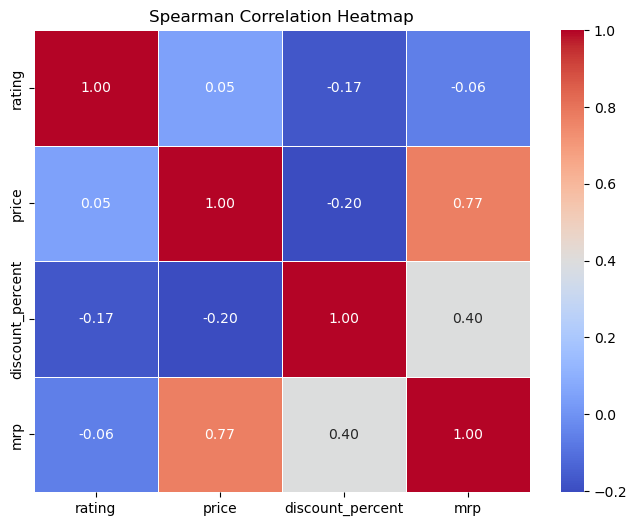

In [61]:
corr_matrix = myntra[['rating', 'price', 'discount_percent', 'mrp']].corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Heatmap")
plt.show()

# 6. Data Preprocessing

#### Before transforming or Scaling I am considering  the copy of originaL dataset

In [62]:
Emyntra=myntra.copy()
Emyntra.head(2)

,name,img,price,mrp,rating,ratingTotal,seller,purl,sub_category,gender,category,discount_percent,is_deep_discount,category_gender,rating_category
0,Men Solid Oversized Cotton,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",532.0,1299.0,4.1,5300,Difference of Opinion,https://www.myntra.com/tshirts/difference-of-o...,tshirts,Male,Clothing,59.04542,1,Clothing_Male,High
1,Men Cotton Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",274.0,499.0,4.2,25400,Roadster,https://www.myntra.com/tshirts/roadster/roadst...,tshirts,Male,Clothing,45.09018,0,Clothing_Male,High


In [63]:
Emyntra.columns

Index(['name', 'img', 'price', 'mrp', 'rating', 'ratingTotal', 'seller',
       'purl', 'sub_category', 'gender', 'category', 'discount_percent',
       'is_deep_discount', 'category_gender', 'rating_category'],
      dtype='object')

## 6.1 Encoding

In [64]:
cat_cols=myntra.select_dtypes(exclude=np.number).columns
cat_cols

Index(['name', 'img', 'seller', 'purl', 'sub_category', 'gender', 'category',
       'category_gender', 'rating_category'],
      dtype='object')

In [65]:
for i in cat_cols:
    print(i)
    print(myntra[i].nunique())
    print('*'*50)

name
78309
**************************************************
img
174116
**************************************************
seller
3825
**************************************************
purl
210888
**************************************************
sub_category
337
**************************************************
gender
3
**************************************************
category
8
**************************************************
category_gender
24
**************************************************
rating_category
3
**************************************************


In [66]:
for i in cat_cols:
    print(i)
    print(myntra[i].unique())
    print('*'*50)

name
['Men Solid Oversized Cotton' 'Men Cotton Pure Cotton T-shirt'
 'Women Pure Cotton T-shirt' ... 'Slim Fit Twill Joggers'
 'Men VK AOP Chino Shorts' 'Men Slim Fit Track Pant']
**************************************************
img
['https://assets.myntassets.com/f_webp,dpr_1.0,q_60,w_210,c_limit,fl_progressive/assets/images/16407468/2021/12/28/fce7ca1e-01ec-4c12-a90f-c7b75abda0e01640669480687-Difference-of-Opinion-Men-Tshirts-4021640669480120-1.jpg;\nhttps://assets.myntassets.com/f_webp,dpr_1.8,q_60,w_210,c_limit,fl_progressive/assets/images/16407468/2021/12/28/fce7ca1e-01ec-4c12-a90f-c7b75abda0e01640669480687-Difference-of-Opinion-Men-Tshirts-4021640669480120-1.jpg;\nhttps://assets.myntassets.com/f_webp,dpr_2.0,q_60,w_210,c_limit,fl_progressive/assets/images/16407468/2021/12/28/fce7ca1e-01ec-4c12-a90f-c7b75abda0e01640669480687-Difference-of-Opinion-Men-Tshirts-4021640669480120-1.jpg;\nhttps://assets.myntassets.com/f_webp,dpr_2.2,q_60,w_210,c_limit,fl_progressive/assets/images/1640

#### Label Encoding

In [67]:
from sklearn.preprocessing import LabelEncoder
le_gender = LabelEncoder()
myntra['gender'] = le_gender.fit_transform(myntra['gender'])

#### Frequency Encoding

In [68]:
myntra['seller_freq'] = myntra['seller'].map(myntra['seller'].value_counts())

In [69]:
myntra['subcat_freq'] = myntra['sub_category'].map(myntra['sub_category'].value_counts())

#### Dummy Encoding

In [70]:
category_dummies = pd.get_dummies(myntra['category'], prefix='category').astype(int)
myntra = pd.concat([myntra.drop(columns=['category']), category_dummies], axis=1)

#### Ordinal Encoding

In [71]:
# Ordinal Encoding for discount_category, price_category, rating_category
ordinal_map = {'Low': 0,'Medium': 1, 'High': 2}

myntra['rating_category'] = myntra['rating_category'].map(ordinal_map)

In [72]:
myntra.head()

,name,img,price,mrp,rating,ratingTotal,seller,purl,sub_category,gender,discount_percent,is_deep_discount,category_gender,rating_category,seller_freq,subcat_freq,category_Accessories,category_Bags and Luggage,category_Care and Beauty,category_Clothing,category_Electronics and Gadgets,category_Footwear,category_Home and Living,category_Toys and Kids Essentials
0,Men Solid Oversized Cotton,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",532.0,1299.0,4.1,5300,Difference of Opinion,https://www.myntra.com/tshirts/difference-of-o...,tshirts,1,59.045420,1,Clothing_Male,2,435,59157,0,0,0,1,0,0,0,0
1,Men Cotton Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",274.0,499.0,4.2,25400,Roadster,https://www.myntra.com/tshirts/roadster/roadst...,tshirts,1,45.090180,0,Clothing_Male,2,8513,59157,0,0,0,1,0,0,0,0
2,Women Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",551.0,1199.0,4.5,3400,DILLINGER,https://www.myntra.com/tshirts/dillinger/dilli...,tshirts,0,54.045038,1,Clothing_Female,2,642,59157,0,0,0,1,0,0,0,0
3,Typography Print T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",296.0,1099.0,4.0,18400,Huetrap,https://www.myntra.com/tshirts/huetrap/huetrap...,tshirts,0,73.066424,1,Clothing_Female,2,652,59157,0,0,0,1,0,0,0,0
4,Printed Round Neck Pure Cotton T-shirt,"https://assets.myntassets.com/f_webp,dpr_1.0,q...",494.0,899.0,4.2,3800,Roadster,https://www.myntra.com/tshirts/roadster/roadst...,tshirts,0,45.050056,0,Clothing_Female,2,8513,59157,0,0,0,1,0,0,0,0


In [73]:
myntra.shape


(270419, 24)

#### Droping unnecessary columns before splitting data

In [74]:
myntra.drop(columns=['name','img','purl'],axis=1,inplace=True)

In [75]:
myntra.head(2)

,price,mrp,rating,ratingTotal,seller,sub_category,gender,discount_percent,is_deep_discount,category_gender,rating_category,seller_freq,subcat_freq,category_Accessories,category_Bags and Luggage,category_Care and Beauty,category_Clothing,category_Electronics and Gadgets,category_Footwear,category_Home and Living,category_Toys and Kids Essentials
0,532.0,1299.0,4.1,5300,Difference of Opinion,tshirts,1,59.04542,1,Clothing_Male,2,435,59157,0,0,0,1,0,0,0,0
1,274.0,499.0,4.2,25400,Roadster,tshirts,1,45.09018,0,Clothing_Male,2,8513,59157,0,0,0,1,0,0,0,0


### 6.2 Splitting Data

In [76]:
from sklearn.model_selection import train_test_split
X = myntra.drop(columns=['rating_category','rating','seller', 'sub_category', 'category_gender'], axis=1)
y = myntra['rating_category']

#Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=42) 

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((216335, 16), (54084, 16), (216335,), (54084,))

In [77]:
X_train.head()

,price,mrp,ratingTotal,gender,discount_percent,is_deep_discount,seller_freq,subcat_freq,category_Accessories,category_Bags and Luggage,category_Care and Beauty,category_Clothing,category_Electronics and Gadgets,category_Footwear,category_Home and Living,category_Toys and Kids Essentials
823028,597.0,1299.0,68,1,54.041570,1,116,59157,0,0,0,1,0,0,0,0
279119,774.0,1800.0,1500,2,57.000000,1,317,3209,1,0,0,0,0,0,0,0
935626,989.0,3299.0,31,1,70.021219,1,807,4491,0,0,0,1,0,0,0,0
54375,679.0,1699.0,8,0,60.035315,1,279,1883,0,0,0,1,0,0,0,0
627209,899.0,999.0,46,0,10.010010,0,85,3021,0,0,0,0,0,1,0,0


## Conclusion: 
The dataset was prepared for machine learning by:

- Handling categorical variables
- Feature encoding
- Train-test split
- Removing unnecessary columns
- Selecting predictor variables

# 7. Classification Modeling

## Classification Approach

The classification task predicts customer ratings as:

- Low
- Medium
- High

Models Evaluated

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report,confusion_matrix,cohen_kappa_score
from sklearn.metrics import roc_auc_score,roc_curve
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.preprocessing import label_binarize

In [79]:
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score,
    cohen_kappa_score, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

mod = []
accu = []
prec = []
rec = []
f1 = []
kappa = []
auc = []

def model_validation_multiclass(model, xtrain, ytrain, xtest, ytest):

    m = model
    m.fit(xtrain, ytrain)

    pred_h = m.predict(xtest)
    pred_s = m.predict_proba(xtest)

    print("Confusion Matrix\n")
    print(confusion_matrix(ytest, pred_h))

    print("\nClassification Report\n")
    print(classification_report(ytest, pred_h))

    classes = np.unique(ytest)
    ytest_bin = label_binarize(ytest, classes=classes)

    if ytest_bin.shape[1] == 1:
        print("ROC AUC cannot be computed for a single class.")
        auc_score = 0
    else:
        auc_score = roc_auc_score(ytest_bin, pred_s, multi_class="ovr")
        print(f"\nMulticlass ROC AUC (OvR): {auc_score:.4f}")

        plt.figure(figsize=(6,5))

        for i in range(len(classes)):
            fpr, tpr, _ = roc_curve(ytest_bin[:, i], pred_s[:, i])
            plt.plot(fpr, tpr, label=f"Class {classes[i]}")

        plt.plot([0,1],[0,1],'r--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {type(model).__name__}")
        plt.legend()
        plt.show()

    # Update Scorecard
    global scorecard

    mod.append(type(model).__name__)
    accu.append(accuracy_score(ytest, pred_h))
    prec.append(precision_score(ytest, pred_h, average="weighted"))
    rec.append(recall_score(ytest, pred_h, average="weighted"))
    f1.append(f1_score(ytest, pred_h, average="weighted"))
    kappa.append(cohen_kappa_score(ytest, pred_h))
    auc.append(auc_score)

    scorecard = pd.DataFrame({
        "Model": mod,
        "Accuracy": accu,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "Cohen Kappa": kappa,
        "ROC AUC": auc
    })

    print("\nClassification Scorecard")
    display(scorecard)

    return m

### Logistic Regression(Base Model)

Confusion Matrix

[[    0     1  1399]
 [    2     0 12060]
 [    3     0 40619]]

Classification Report

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1400
           1       0.00      0.00      0.00     12062
           2       0.75      1.00      0.86     40622

    accuracy                           0.75     54084
   macro avg       0.25      0.33      0.29     54084
weighted avg       0.56      0.75      0.64     54084


Multiclass ROC AUC (OvR): 0.5789


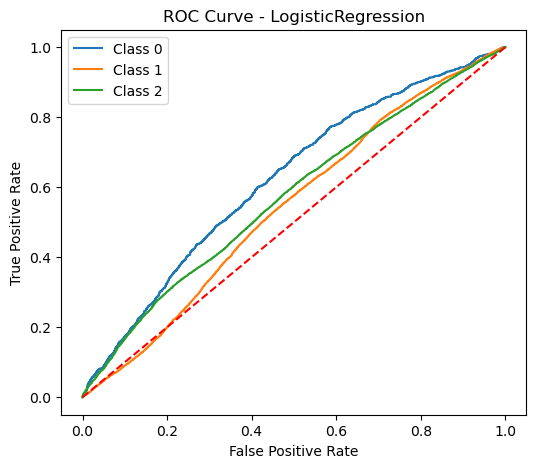


Classification Scorecard


,Model,Accuracy,Precision,Recall,F1 Score,Cohen Kappa,ROC AUC
0,LogisticRegression,0.751035,0.564158,0.751035,0.64432,0.000086,0.578899


In [80]:
lg_model=model_validation_multiclass(LogisticRegression(random_state=42),X_train,y_train,X_test,y_test)

#### Decision Tree

Confusion Matrix

[[  534   372   494]
 [  429  6394  5239]
 [  557  6177 33888]]

Classification Report

              precision    recall  f1-score   support

           0       0.35      0.38      0.37      1400
           1       0.49      0.53      0.51     12062
           2       0.86      0.83      0.84     40622

    accuracy                           0.75     54084
   macro avg       0.57      0.58      0.57     54084
weighted avg       0.76      0.75      0.76     54084


Multiclass ROC AUC (OvR): 0.6990


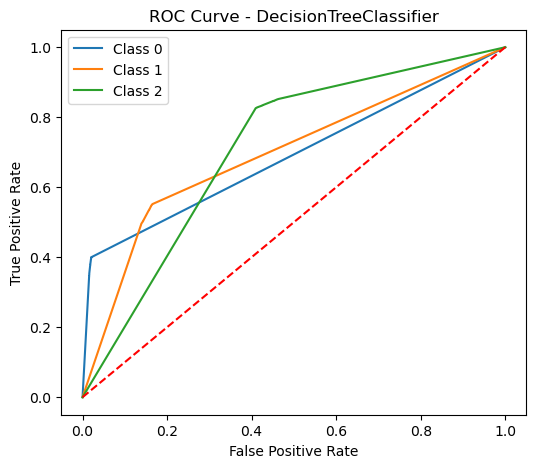


Classification Scorecard


,Model,Accuracy,Precision,Recall,F1 Score,Cohen Kappa,ROC AUC
0,LogisticRegression,0.751035,0.564158,0.751035,0.644320,0.000086,0.578899
1,DecisionTreeClassifier,0.754678,0.761681,0.754678,0.757923,0.379974,0.699032


In [81]:
dt_model=model_validation_multiclass(DecisionTreeClassifier(random_state=42),X_train,y_train,X_test,y_test)

#### Random Forest

Confusion Matrix

[[  461   304   635]
 [  181  5535  6346]
 [  131  2925 37566]]

Classification Report

              precision    recall  f1-score   support

           0       0.60      0.33      0.42      1400
           1       0.63      0.46      0.53     12062
           2       0.84      0.92      0.88     40622

    accuracy                           0.81     54084
   macro avg       0.69      0.57      0.61     54084
weighted avg       0.79      0.81      0.79     54084


Multiclass ROC AUC (OvR): 0.8433


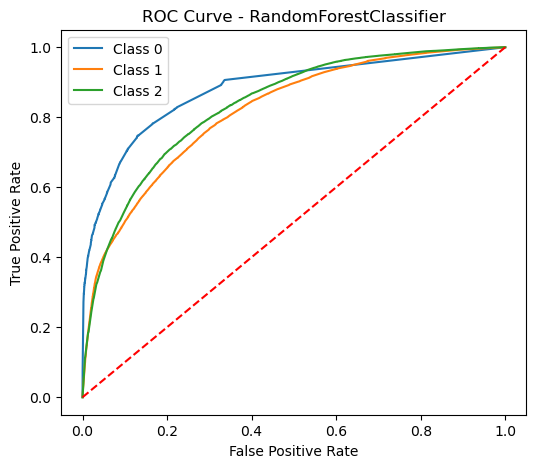


Classification Scorecard


,Model,Accuracy,Precision,Recall,F1 Score,Cohen Kappa,ROC AUC
0,LogisticRegression,0.751035,0.564158,0.751035,0.644320,0.000086,0.578899
1,DecisionTreeClassifier,0.754678,0.761681,0.754678,0.757923,0.379974,0.699032
2,RandomForestClassifier,0.805451,0.789677,0.805451,0.792107,0.435835,0.843296


In [82]:
rf_model=model_validation_multiclass(RandomForestClassifier(random_state=42),X_train,y_train,X_test,y_test)

#### XGBClassifier

Confusion Matrix

[[   93   225  1082]
 [   49  1329 10684]
 [   44   737 39841]]

Classification Report

              precision    recall  f1-score   support

           0       0.50      0.07      0.12      1400
           1       0.58      0.11      0.19     12062
           2       0.77      0.98      0.86     40622

    accuracy                           0.76     54084
   macro avg       0.62      0.39      0.39     54084
weighted avg       0.72      0.76      0.69     54084


Multiclass ROC AUC (OvR): 0.7868


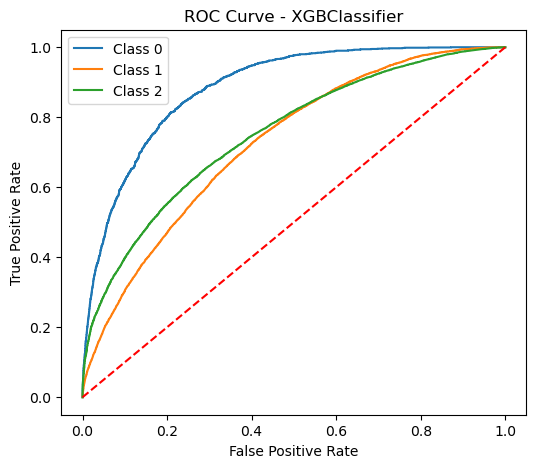


Classification Scorecard


,Model,Accuracy,Precision,Recall,F1 Score,Cohen Kappa,ROC AUC
0,LogisticRegression,0.751035,0.564158,0.751035,0.644320,0.000086,0.578899
1,DecisionTreeClassifier,0.754678,0.761681,0.754678,0.757923,0.379974,0.699032
2,RandomForestClassifier,0.805451,0.789677,0.805451,0.792107,0.435835,0.843296
3,XGBClassifier,0.762943,0.722166,0.762943,0.693248,0.134108,0.786849


In [83]:
xgb_model=model_validation_multiclass(XGBClassifier(random_state=42),X_train,y_train,X_test,y_test)

In [84]:
scorecard

,Model,Accuracy,Precision,Recall,F1 Score,Cohen Kappa,ROC AUC
0,LogisticRegression,0.751035,0.564158,0.751035,0.644320,0.000086,0.578899
1,DecisionTreeClassifier,0.754678,0.761681,0.754678,0.757923,0.379974,0.699032
2,RandomForestClassifier,0.805451,0.789677,0.805451,0.792107,0.435835,0.843296
3,XGBClassifier,0.762943,0.722166,0.762943,0.693248,0.134108,0.786849


**Random Forest Classifier** achieved the best overall performance, recording the highest Accuracy, F1 Score, Cohen's Kappa, and ROC AUC among all evaluated models.

## Feature Importance -- Random Forest Classifier

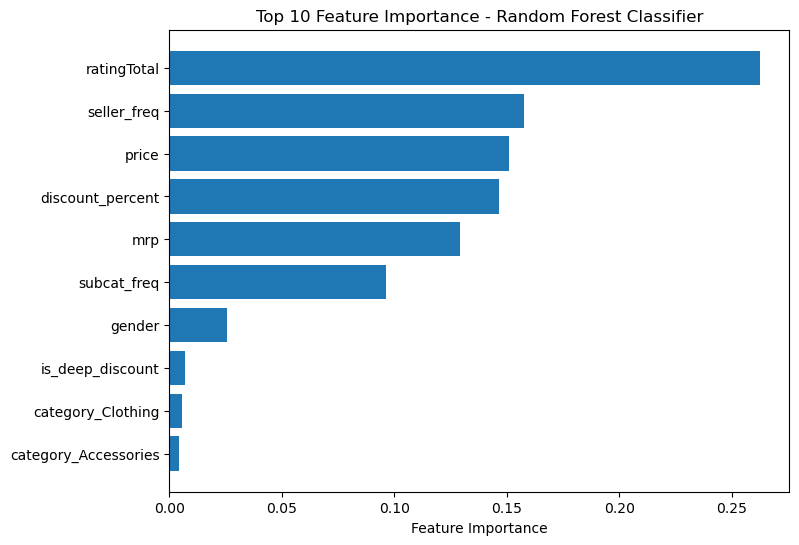

,Feature,Importance
2,ratingTotal,0.262539
6,seller_freq,0.157712
0,price,0.151020
4,discount_percent,0.146509
1,mrp,0.129316
7,subcat_freq,0.096330
3,gender,0.025770
5,is_deep_discount,0.006946
11,category_Clothing,0.005798
8,category_Accessories,0.004447


In [96]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 10 Features
plt.figure(figsize=(8,6))
plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importance - Random Forest Classifier")
plt.show()

feature_importance.head(10)

### Insights

- **ratingTotal** is the most influential feature for predicting customer rating categories, followed by **seller frequency**, **price**, and **discount percentage**.
- Pricing-related features (**price**, **MRP**, and **discount percentage**) play a significant role in classifying products into Low, Medium, and High rating categories.
- Category-based features contribute relatively less to the classification model, indicating that customer engagement and pricing have a greater influence on rating categories.

# 8. Regression Modeling

## Regression Approach

Unlike classification, regression predicts the exact customer rating.

Models Evaluated

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

Performance Metrics

- MAE
- RMSE
- R² Score

In [85]:
from sklearn.model_selection import train_test_split
X = myntra.drop(columns=['rating_category','rating','seller', 'sub_category', 'category_gender'], axis=1)
y = myntra['rating']

#Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=42) 

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((216335, 16), (54084, 16), (216335,), (54084,))

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mod = []
rmse = []
mae = []
r2 = []

def model_validation_regression(model, xtrain, ytrain, xtest, ytest):

    m = model
    m.fit(xtrain, ytrain)

    pred = m.predict(xtest)

    mae_score = mean_absolute_error(ytest, pred)
    rmse_score = np.sqrt(mean_squared_error(ytest, pred))
    r2score = r2_score(ytest, pred)

    print(f"MAE      : {mae_score:.4f}")
    print(f"RMSE     : {rmse_score:.4f}")
    print(f"R² Score : {r2score:.4f}")

    # Actual vs Predicted
    plt.figure(figsize=(6,6))
    plt.scatter(ytest, pred, alpha=0.5)
    plt.plot([ytest.min(), ytest.max()],
             [ytest.min(), ytest.max()],
             color='red', linestyle='--')
    plt.xlabel("Actual Rating")
    plt.ylabel("Predicted Rating")
    plt.title(f"Actual vs Predicted - {type(model).__name__}")
    plt.show()

    # Residual Plot
    residuals = ytest - pred

    plt.figure(figsize=(6,4))
    plt.scatter(pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted Rating")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot - {type(model).__name__}")
    plt.show()

    # Update Scorecard
    global regression_scorecard

    mod.append(type(model).__name__)
    mae.append(mae_score)
    rmse.append(rmse_score)
    r2.append(r2score)

    regression_scorecard = pd.DataFrame({
        "Model": mod,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })

    print("\nRegression Scorecard")
    display(regression_scorecard)

    return m

MAE      : 0.3606
RMSE     : 0.5001
R² Score : 0.0254


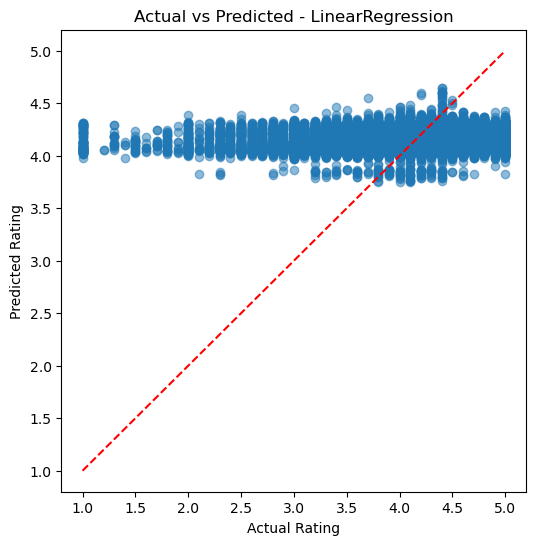

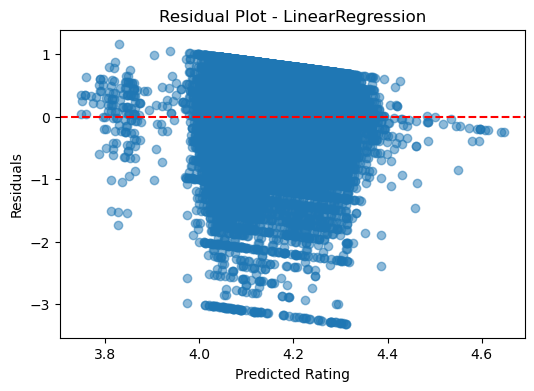


Regression Scorecard


,Model,MAE,RMSE,R² Score
0,LinearRegression,0.360619,0.500091,0.025447


In [87]:
from sklearn.linear_model import LinearRegression
lr_model = model_validation_regression(LinearRegression(),X_train,y_train,X_test,y_test)

MAE      : 0.3102
RMSE     : 0.5345
R² Score : -0.1132


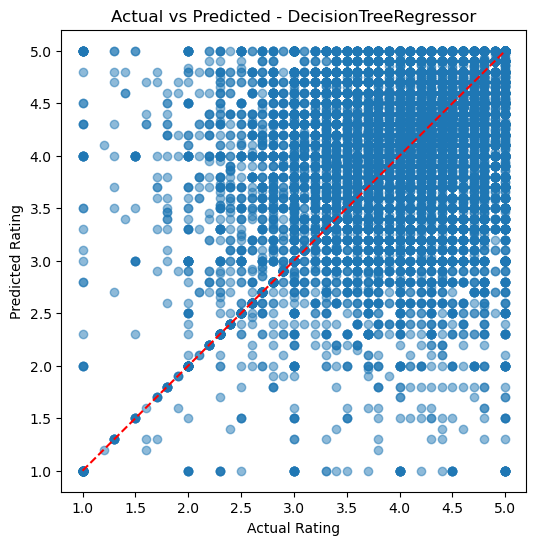

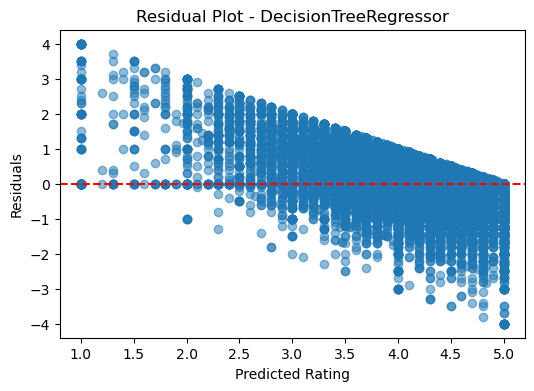


Regression Scorecard


,Model,MAE,RMSE,R² Score
0,LinearRegression,0.360619,0.500091,0.025447
1,DecisionTreeRegressor,0.310224,0.534476,-0.113176


In [88]:
from sklearn.tree import DecisionTreeRegressor

dt = model_validation_regression(DecisionTreeRegressor(random_state=42),X_train,y_train,X_test,y_test)

MAE      : 0.2722
RMSE     : 0.4154
R² Score : 0.3277


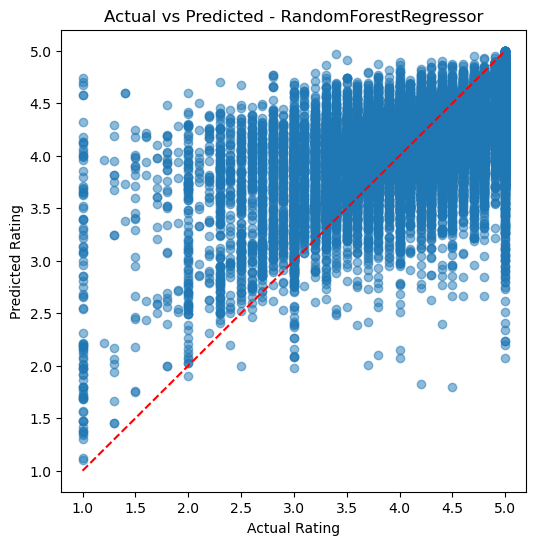

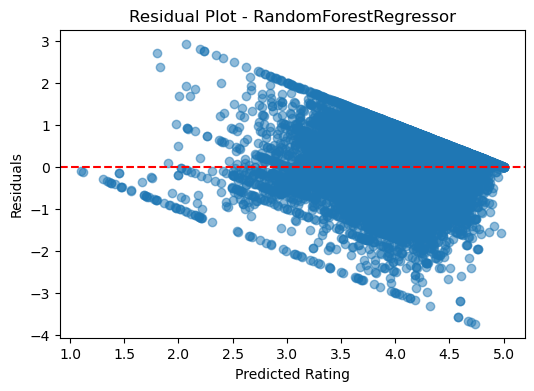


Regression Scorecard


,Model,MAE,RMSE,R² Score
0,LinearRegression,0.360619,0.500091,0.025447
1,DecisionTreeRegressor,0.310224,0.534476,-0.113176
2,RandomForestRegressor,0.272164,0.415370,0.327678


In [89]:
from sklearn.ensemble import RandomForestRegressor

rf= model_validation_regression(RandomForestRegressor(random_state=42),X_train,y_train,X_test,y_test)

MAE      : 0.3249
RMSE     : 0.4557
R² Score : 0.1907


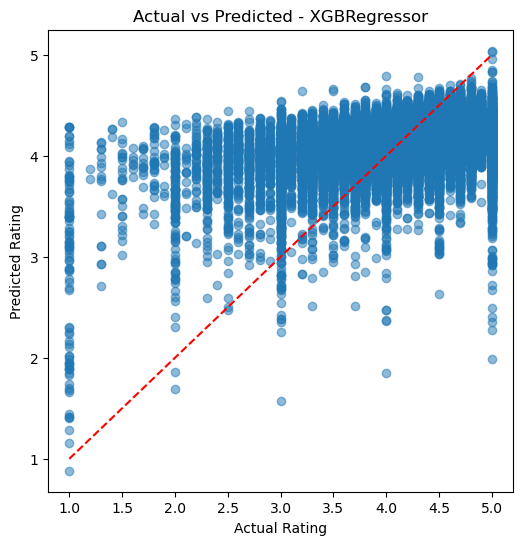

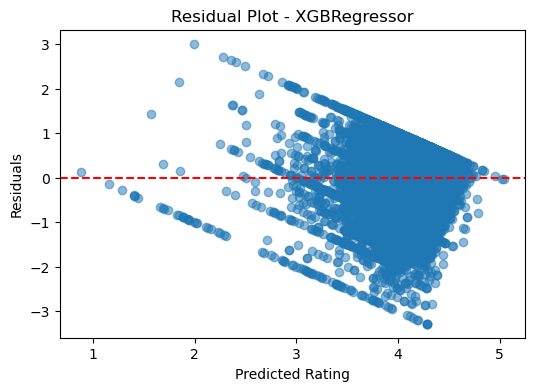


Regression Scorecard


,Model,MAE,RMSE,R² Score
0,LinearRegression,0.360619,0.500091,0.025447
1,DecisionTreeRegressor,0.310224,0.534476,-0.113176
2,RandomForestRegressor,0.272164,0.415370,0.327678
3,XGBRegressor,0.324928,0.455737,0.190651


In [90]:
from xgboost import XGBRegressor

xgb_= model_validation_regression( XGBRegressor(random_state=42), X_train, y_train, X_test, y_test)

In [91]:
regression_scorecard

,Model,MAE,RMSE,R² Score
0,LinearRegression,0.360619,0.500091,0.025447
1,DecisionTreeRegressor,0.310224,0.534476,-0.113176
2,RandomForestRegressor,0.272164,0.415370,0.327678
3,XGBRegressor,0.324928,0.455737,0.190651


**Random Forest Regressor** achieved the best overall performance, producing the lowest MAE and RMSE along with the highest R² score.

## Feature Importance --  Random Forest Regressor

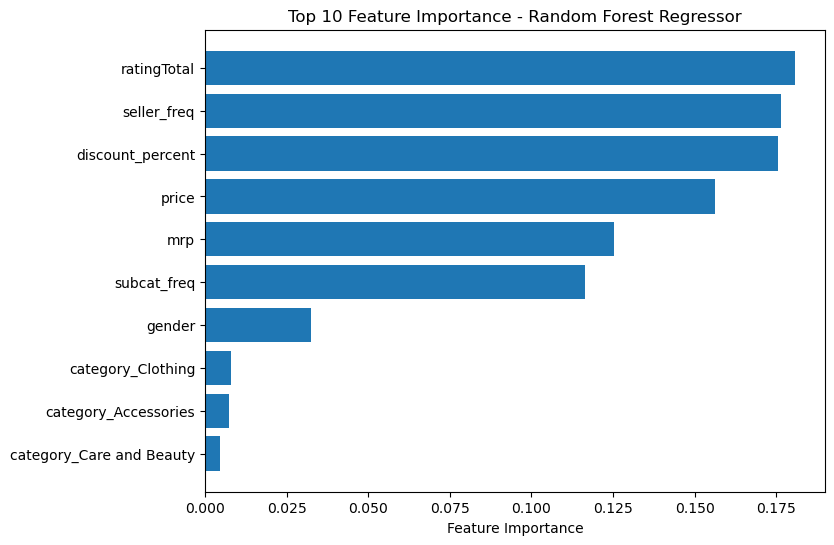

,Feature,Importance
2,ratingTotal,0.180881
6,seller_freq,0.176597
4,discount_percent,0.175522
0,price,0.156136
1,mrp,0.125340
7,subcat_freq,0.116397
3,gender,0.032555
11,category_Clothing,0.008029
8,category_Accessories,0.007236
10,category_Care and Beauty,0.004631


In [100]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 10 Features
plt.figure(figsize=(8,6))
plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importance - Random Forest Regressor")
plt.show()

feature_importance.head(10)

### Insights

- **ratingTotal** is the most influential feature for predicting customer ratings.
- **seller_freq**, **discount_percent**, **price**, and **MRP** also have a significant impact on the model's predictions.
- Product popularity, pricing, and discount-related features contribute more to customer ratings than category-based features.

# 9. Classification vs Regression

## Comparison of Modeling Approaches

| Classification | Regression |
|----------------|------------|
| Predicts rating categories | Predicts exact rating |
| Accuracy | RMSE |
| Precision | MAE |
| Recall | R² Score |
| F1 Score | |

### Key Findings

- Classification models are suitable for categorizing products into predefined rating groups.
- Regression models provide more precise numerical predictions.
- Random Forest achieved the best performance for both classification and regression tasks.

### Feature Importance Comparison

Both the classification and regression models identified similar key predictors, with **ratingTotal**, **seller_freq**, **price**, and **discount_percent** consistently ranking among the most important features. This indicates that these variables play a major role in determining both customer rating categories and exact customer ratings.

# 10 Business Recommendations

Based on the analysis:

- Improve quality for products predicted to receive low ratings.
- Monitor seller performance using historical customer ratings.
- Optimize pricing strategies for heavily discounted products.
- Prioritize inventory for consistently high-rated products.
- Use predictive models to identify products requiring proactive quality improvements.

# 11. Conclusion

This project successfully demonstrates the complete machine learning workflow for customer rating prediction.

Key achievements include:

- Comprehensive Exploratory Data Analysis
- Feature Engineering
- Statistical Testing
- Classification Modeling
- Regression Modeling
- Model Comparison
- Business Recommendations

Among the evaluated models, **Random Forest** delivered the strongest overall performance for both classification and regression, indicating its effectiveness in capturing nonlinear relationships within the dataset.

The project highlights how machine learning can support data-driven decision-making in e-commerce by improving customer satisfaction and product performance.